<a href="https://www.kaggle.com/code/gowthambatthula/fracseg2-0?scriptVersionId=333165745" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
#1
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Verify Dual GPU environment
print(f"PyTorch Version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using device: {device}")
print(f"Number of GPUs available: {num_gpus}")
if num_gpus < 2:
    print("WARNING: Less than 2 GPUs detected. Check Kaggle Accelerator settings.")
else:
    for i in range(num_gpus):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

# Set random seed for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

PyTorch Version: 2.10.0+cu128
Using device: cuda
Number of GPUs available: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [2]:
# Cell 1.5: Auto-Find Dataset Path
import os

correct_base_dir = None
for root, dirs, files in os.walk('/kaggle/input'):
    # Look for the folder that contains the 'train', 'val', and 'test' subdirectories
    if 'train' in dirs and 'val' in dirs and 'test' in dirs:
        correct_base_dir = root
        break

if correct_base_dir:
    print(f"✅ FOUND IT! Your exact BASE_DIR is:\n{correct_base_dir}")
else:
    print("❌ Could not find the train/val/test folders. Let's check what's actually inside /kaggle/input:")
    for dirname, _, _ in os.walk('/kaggle/input'):
        print(dirname)

✅ FOUND IT! Your exact BASE_DIR is:
/kaggle/input/datasets/gowthambatthula/finaldata/Final_Dataset


In [3]:
# Cell 2: Updated Configuration
class Config:
    BASE_DIR = '/kaggle/input/datasets/gowthambatthula/finaldata/Final_Dataset'

    IMG_HEIGHT = 256
    IMG_WIDTH  = 256
    CHANNELS   = 1

    BATCH_SIZE     = 16        # keep 16 for dual T4 throughput
    EPOCHS         = 60       # paper trains 100 — yours stopped at 24, still converging
    LEARNING_RATE  = 1e-4
    NUM_WORKERS    = 2
    PATIENCE       = 15
    SAVE_PATH      = '/kaggle/working/best_unet.pth'

    TRAIN_IMG_FRAC  = os.path.join(BASE_DIR, "train/images/fractured/")
    TRAIN_IMG_NON   = os.path.join(BASE_DIR, "train/images/non_fractured/")
    TRAIN_MASK_FRAC = os.path.join(BASE_DIR, "train/masks/fractured/")

    VAL_IMG_FRAC    = os.path.join(BASE_DIR, "val/images/fractured/")
    VAL_IMG_NON     = os.path.join(BASE_DIR, "val/images/non_fractured/")
    VAL_MASK_FRAC   = os.path.join(BASE_DIR, "val/masks/fractured/")

    TEST_IMG_FRAC   = os.path.join(BASE_DIR, "test/images/fractured/")
    TEST_IMG_NON    = os.path.join(BASE_DIR, "test/images/non_fractured/")
    TEST_MASK_FRAC  = os.path.join(BASE_DIR, "test/masks/fractured/")

config = Config()
print("Configuration loaded ✓  (60 epochs | Dual T4 | Grayscale)")

Configuration loaded ✓  (60 epochs | Dual T4 | Grayscale)


In [4]:
#3
# Cell 3: Robust Path Loading
def load_split_paths(img_frac_dir, img_non_dir, mask_frac_dir, split_name="Set"):
    image_paths, mask_paths, labels = [], [], []
    missing_masks = 0
    
    # Process Fractured
    if os.path.exists(img_frac_dir):
        for filename in sorted(os.listdir(img_frac_dir)):
            img_path = os.path.join(img_frac_dir, filename)
            
            # Guess 1: Exact matching filename (e.g., image.jpg -> image.jpg)
            mask_path = os.path.join(mask_frac_dir, filename)
            
            # Guess 2: If exact match fails, check for other extensions (e.g., image.jpg -> image.png)
            if not os.path.exists(mask_path) and os.path.exists(mask_frac_dir):
                base_name = os.path.splitext(filename)[0]
                for ext in ['.png', '.jpg', '.jpeg', '.tif']:
                    temp_path = os.path.join(mask_frac_dir, base_name + ext)
                    if os.path.exists(temp_path):
                        mask_path = temp_path
                        break
                        
            # Add to list if a mask was found
            if os.path.exists(mask_path):
                image_paths.append(img_path)
                mask_paths.append(mask_path)
                labels.append(1)
            else:
                missing_masks += 1
    else:
        print(f"❌ {split_name} Fractured Images Directory NOT found: {img_frac_dir}")
                
    # Process Non-Fractured
    if os.path.exists(img_non_dir):
        for filename in sorted(os.listdir(img_non_dir)):
            img_path = os.path.join(img_non_dir, filename)
            image_paths.append(img_path)
            mask_paths.append(None) # No mask needed for non-fractured
            labels.append(0)
            
    if missing_masks > 0:
        print(f"⚠️ WARNING in {split_name}: Found {missing_masks} fractured images, but their MASKS are missing or named differently!")
            
    return image_paths, mask_paths, labels

# Load paths for all sets
train_imgs, train_masks, train_labels = load_split_paths(config.TRAIN_IMG_FRAC, config.TRAIN_IMG_NON, config.TRAIN_MASK_FRAC, "Train")
val_imgs, val_masks, val_labels = load_split_paths(config.VAL_IMG_FRAC, config.VAL_IMG_NON, config.VAL_MASK_FRAC, "Val")
test_imgs, test_masks, test_labels = load_split_paths(config.TEST_IMG_FRAC, config.TEST_IMG_NON, config.TEST_MASK_FRAC, "Test")

print("\n--- FINAL DATASET COUNTS ---")
print(f"Train set: {len(train_imgs)} images ({sum(train_labels)} Fractured, {len(train_labels)-sum(train_labels)} Non-Fractured)")
print(f"Val set:   {len(val_imgs)} images ({sum(val_labels)} Fractured, {len(val_labels)-sum(val_labels)} Non-Fractured)")
print(f"Test set:  {len(test_imgs)} images ({sum(test_labels)} Fractured, {len(test_labels)-sum(test_labels)} Non-Fractured)")


--- FINAL DATASET COUNTS ---
Train set: 4360 images (2004 Fractured, 2356 Non-Fractured)
Val set:   613 images (108 Fractured, 505 Non-Fractured)
Test set:  613 images (108 Fractured, 505 Non-Fractured)


In [5]:
# Cell 3.5: Clean Corrupted Images
import os

def remove_corrupted_images(img_paths, mask_paths, labels, split_name):
    valid_imgs, valid_masks, valid_labels = [], [], []
    removed_count = 0
    
    for img, mask, label in zip(img_paths, mask_paths, labels):
        is_valid = True
        # Check if JPEG is missing its End-Of-Image (EOI) marker
        if img.lower().endswith(('.jpg', '.jpeg')):
            if os.path.getsize(img) > 2:
                with open(img, 'rb') as f:
                    f.seek(-2, os.SEEK_END)
                    if f.read() != b'\xff\xd9':
                        is_valid = False
            else:
                is_valid = False
                
        if is_valid:
            valid_imgs.append(img)
            valid_masks.append(mask)
            valid_labels.append(label)
        else:
            removed_count += 1
            
    if removed_count > 0:
        print(f"🧹 Removed {removed_count} corrupted images from {split_name} set.")
    else:
        print(f"✅ {split_name} set is clean!")
        
    return valid_imgs, valid_masks, valid_labels

# Filter all datasets before they reach the DataLoader
train_imgs, train_masks, train_labels = remove_corrupted_images(train_imgs, train_masks, train_labels, "Train")
val_imgs, val_masks, val_labels = remove_corrupted_images(val_imgs, val_masks, val_labels, "Val")
test_imgs, test_masks, test_labels = remove_corrupted_images(test_imgs, test_masks, test_labels, "Test")

🧹 Removed 61 corrupted images from Train set.
🧹 Removed 14 corrupted images from Val set.
🧹 Removed 12 corrupted images from Test set.


In [6]:
# Cell 4: Grayscale Preprocessing Pipelines
class ContrastStretch(A.ImageOnlyTransform):
    """Applies p2-p98 contrast stretching to 1-channel images."""
    def __init__(self, p_low=2, p_high=98, always_apply=True, p=1.0):
        super(ContrastStretch, self).__init__(always_apply, p)
        self.p_low = p_low
        self.p_high = p_high

    def apply(self, img, **params):
        low, high = np.percentile(img, (self.p_low, self.p_high))
        if high <= low:
            return img
        stretched = np.clip((img - low) / (high - low) * 255.0, 0, 255)
        return stretched.astype(np.uint8)

# Normalization now expects a single mean/std value
train_transforms = A.Compose([
    ContrastStretch(p_low=2, p_high=98),
    A.Resize(config.IMG_HEIGHT, config.IMG_WIDTH),
    A.Normalize(mean=(0.5,), std=(0.5,)), 
    ToTensorV2()
])

val_test_transforms = A.Compose([
    ContrastStretch(p_low=2, p_high=98),
    A.Resize(config.IMG_HEIGHT, config.IMG_WIDTH),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])
print("Grayscale Preprocessing pipelines compiled.")

Grayscale Preprocessing pipelines compiled.


In [7]:
# Cell 5: Grayscale Dataset Class
class FractureDataset(Dataset):
    def __init__(self, image_paths, mask_paths, labels, transforms=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image strictly as Grayscale
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(f"Could not load image at path: {img_path}")
            
        # Handle Masks
        mask_path = self.mask_paths[idx]
        if mask_path is not None and os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            
            # --- Shape Safety Fix (for 2D arrays) ---
            if mask.shape != image.shape:
                mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
                
            _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        else:
            mask = np.zeros_like(image)

        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        mask = mask.float() / 255.0 if mask.max() > 1.0 else mask.float()
        mask = mask.unsqueeze(0) 
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        return image, mask, label

print("Grayscale Dataset class declared with Shape Safety.")

Grayscale Dataset class declared with Shape Safety.


In [8]:
#6
# Instantiate dataset objects
train_dataset = FractureDataset(train_imgs, train_masks, train_labels, transforms=train_transforms)
val_dataset = FractureDataset(val_imgs, val_masks, val_labels, transforms=val_test_transforms)
test_dataset = FractureDataset(test_imgs, test_masks, test_labels, transforms=val_test_transforms)

# Calculate balancing metrics for WeightedRandomSampler
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[label] for label in train_labels])
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Build DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, sampler=sampler, num_workers=config.NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS, pin_memory=True)

print(f"Data loaders created. Train Batch count: {len(train_loader)}")

Data loaders created. Train Batch count: 269


Images shape: torch.Size([16, 1, 256, 256]) | Masks shape: torch.Size([16, 1, 256, 256])


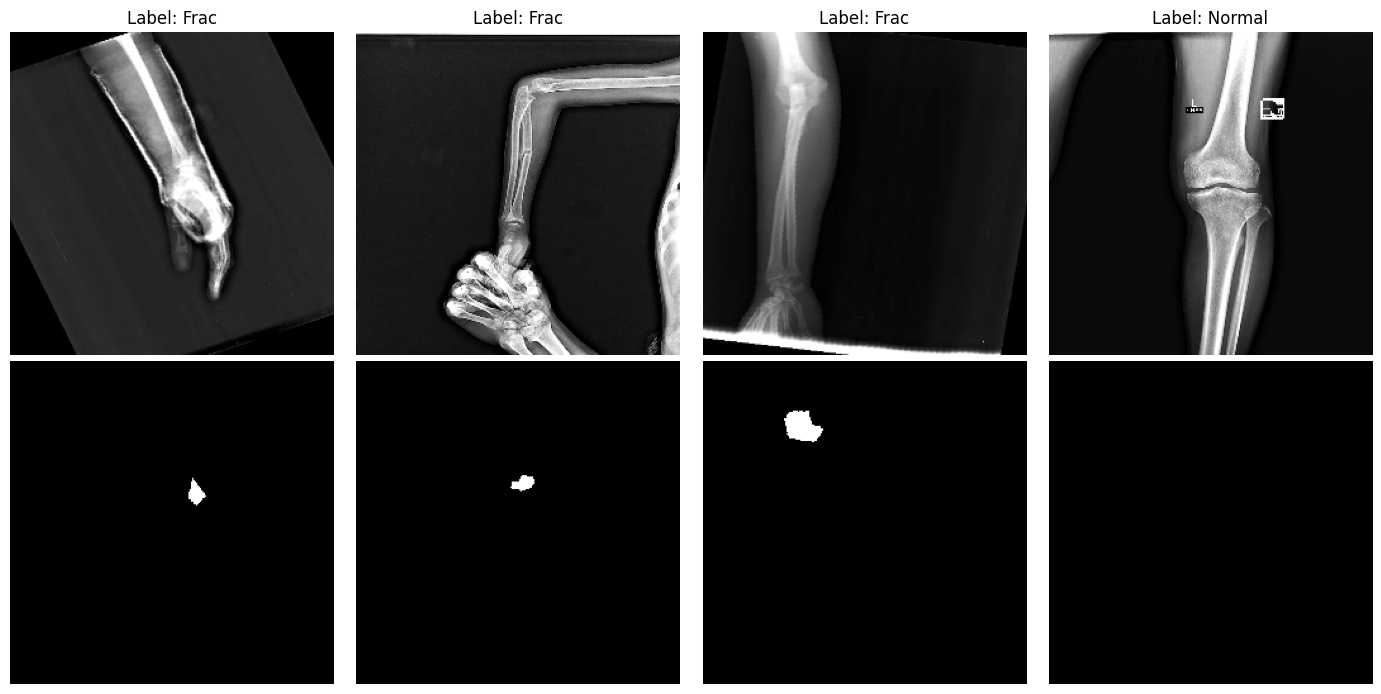

In [9]:
# Cell 7: Verify Batch
images, masks, labels = next(iter(train_loader))
print(f"Images shape: {images.shape} | Masks shape: {masks.shape}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(images[i][0].numpy(), cmap='gray')
    axes[0, i].set_title(f"Label: {'Frac' if labels[i]==1 else 'Normal'}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(masks[i][0].numpy(), cmap='bone')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [10]:
#8
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(UNet, self).__init__()

        def double_conv(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        # Encoder Blocks
        self.enc1 = double_conv(in_channels, 64)
        self.enc2 = double_conv(64, 128)
        self.enc3 = double_conv(128, 256)
        self.enc4 = double_conv(256, 512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck - Standardized to exactly 1024 channels
        self.bottleneck = double_conv(512, 1024)

        # Decoder Upsampling Blocks
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = double_conv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = double_conv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = double_conv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = double_conv(128, 64)

        # Output Head (Only the Segmentation Mask)
        self.final_mask = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.dec4(d4)
        y3 = self.up3(d4)
        y3 = torch.cat((y3, e3), dim=1)
        y3 = self.dec3(y3)
        y2 = self.up2(y3)
        y2 = torch.cat((y2, e2), dim=1)
        y2 = self.dec2(y2)
        y1 = self.up1(y2)
        y1 = torch.cat((y1, e1), dim=1)
        y1 = self.dec1(y1)

        # Only return the mask
        mask_out = self.final_mask(y1)
        return mask_out

print("Strict Paper U-Net model initialized (Segmentation Only).")

Strict Paper U-Net model initialized (Segmentation Only).


In [11]:
# Cell 9: Fixed AWC Loss — Per-image Dice + Fractured-only Dice signal

import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, true_mask):
        probs = torch.sigmoid(logits)

        # ✅ FIX: Per-image Dice (not flattened batch)
        B = probs.size(0)
        probs     = probs.view(B, -1)
        true_mask = true_mask.view(B, -1)

        intersection = (probs * true_mask).sum(dim=1)
        dice = (2. * intersection + self.smooth) / (
               probs.sum(dim=1) + true_mask.sum(dim=1) + self.smooth)

        return (1.0 - dice).mean()


class AWCLoss(nn.Module):
    def __init__(self, pos_weight_val=3.0):
        super(AWCLoss, self).__init__()
        self.pos_weight = torch.tensor([pos_weight_val]).to(device)
        self.bce  = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)
        self.dice = DiceLoss()

    def forward(self, pred_mask, true_mask, labels, alpha):
        # BCE runs on ALL images — still penalizes false positives on non-fractured
        loss_bce = self.bce(pred_mask, true_mask)

        # ✅ FIX: Dice only on fractured images where mask is meaningful
        frac_idx = labels.bool()
        if frac_idx.any():
            loss_dice = self.dice(pred_mask[frac_idx], true_mask[frac_idx])
        else:
            loss_dice = torch.tensor(0.0, device=pred_mask.device)

        return ((1.0 - alpha) * loss_bce) + (alpha * loss_dice)

print("Fixed AWC Loss compiled — per-image Dice, fractured-only segmentation signal.")

Fixed AWC Loss compiled — per-image Dice, fractured-only segmentation signal.


In [12]:
# Cell 10: AWC Loss 
import torch, torch.nn as nn, math

class DiceLoss(nn.Module):
    """
    Per-image Dice averaged across batch.
    Per-image (not batch-flat) ensures small fracture regions
    contribute equally to the gradient — key for hairline fractures.
    """
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, true_mask):
        probs     = torch.sigmoid(logits)
        B         = probs.size(0)
        probs     = probs.view(B, -1)
        true_mask = true_mask.view(B, -1)

        intersection = (probs * true_mask).sum(dim=1)
        union        = probs.sum(dim=1) + true_mask.sum(dim=1)
        dice         = (2. * intersection + self.smooth) / (union + self.smooth)
        return (1.0 - dice).mean()


class AWCLoss(nn.Module):
    """
    Adaptive Weighted Combined Loss — paper Eq. 5.

        Loss(t) = α(t)·Dice_fractured  +  β(t)·BCE_all

    α(t) [Dice weight] increases  0.5 → 1.0  over training
    β(t) [BCE  weight] starts high, eases mid-training, rises briefly at end

    Paper parameters  (Section 4.2):
        αstart=0.5, αend=1.0, βstart=0.5, βend=1.0, λ=0.1, W1=W2=0.5

    Our improvement over the paper:
        Dice is restricted to fractured images only.
        Non-fractured images have all-zero masks — including them in Dice
        trains the model to predict blank masks (blank = zero Dice loss).
        BCE still runs on ALL images to penalise false positives.
    """
    def __init__(self,
                 pos_weight_val = 3.0,
                 alpha_start    = 0.5,
                 alpha_end      = 1.0,
                 beta_start     = 0.5,
                 beta_end       = 1.0,
                 W1             = 0.5,
                 W2             = 0.5,
                 lambda_param   = 0.1):
        super().__init__()
        self.alpha_start  = alpha_start
        self.alpha_end    = alpha_end
        self.beta_start   = beta_start
        self.beta_end     = beta_end
        self.W1           = W1
        self.W2           = W2
        self.lam          = lambda_param

        self.bce  = nn.BCEWithLogitsLoss(
                        pos_weight=torch.tensor([pos_weight_val]).to(device))
        self.dice = DiceLoss()

    # ── paper Eq. 5 top — Dice weight, increases epoch-by-epoch ──────────
    def _alpha(self, t, T):
        lin = self.alpha_start + (self.alpha_end - self.alpha_start) * (t / T)
        exp = self.alpha_start + (self.alpha_end - self.alpha_start) * \
              (1.0 - math.exp(-self.lam * t))
        return self.W1 * lin + self.W2 * exp

    # ── paper Eq. 5 bottom — BCE weight, high early then eases ───────────
    def _beta(self, t, T):
        lin = self.beta_start + (self.beta_end - self.beta_start) * ((T - t) / T)
        exp = self.beta_start + (self.beta_end - self.beta_start) * \
              math.exp(-self.lam * (T - t))
        return self.W1 * lin + self.W2 * exp

    def forward(self, pred_mask, true_mask, labels, t, T):
        alpha = self._alpha(t, T)
        beta  = self._beta(t, T)

        # BCE on ALL images (fractured + non-fractured)
        loss_bce = self.bce(pred_mask, true_mask)

        # Dice ONLY on fractured images
        frac_idx = labels.bool()
        if frac_idx.any():
            loss_dice = self.dice(pred_mask[frac_idx], true_mask[frac_idx])
        else:
            loss_dice = torch.tensor(0.0, device=pred_mask.device)

        return alpha * loss_dice + beta * loss_bce, alpha, beta


print("AWC Loss (Radillah et al. 2025) compiled.")
print("  α : 0.50 → 1.00  [Dice weight, increases]")
print("  β : high early → eases mid → slight rise at end  [BCE weight]")
print("  Dice scope : fractured images only  |  BCE scope : all images")

AWC Loss (Radillah et al. 2025) compiled.
  α : 0.50 → 1.00  [Dice weight, increases]
  β : high early → eases mid → slight rise at end  [BCE weight]
  Dice scope : fractured images only  |  BCE scope : all images


In [13]:
# Cell 11: Model, Optimizer, Criterion, EarlyStopping

base_model = UNet(in_channels=config.CHANNELS, out_channels=1)
if torch.cuda.device_count() > 1:
    print(f"Distributing across {torch.cuda.device_count()} GPUs.")
    model = nn.DataParallel(base_model)
else:
    model = base_model
model = model.to(device)

# Paper parameters passed directly into criterion
criterion = AWCLoss(
    pos_weight_val = 3.0,
    alpha_start    = 0.5,
    alpha_end      = 1.0,
    beta_start     = 0.5,
    beta_end       = 1.0,
    W1             = 0.5,
    W2             = 0.5,
    lambda_param   = 0.1
)

optimizer = optim.AdamW(model.parameters(),
                        lr=config.LEARNING_RATE, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5)


class EarlyStopping:
    """
    Monitors VAL DICE (higher = better).
    Previous version monitored val loss — which is misleading because
    val loss is dominated by easy non-fractured BCE and does not reflect
    whether the model is actually finding fractures.
    """
    def __init__(self, patience=15):
        self.patience   = patience
        self.counter    = 0
        self.best       = None
        self.early_stop = False

    def __call__(self, val_dice):
        if self.best is None or val_dice > self.best:
            self.best   = val_dice
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=15)
print("Model, criterion, optimizer and early stopping ready.")

Distributing across 2 GPUs.
Model, criterion, optimizer and early stopping ready.


In [14]:
# Cell 12: Training Loop — paper AWC + save by val Dice

import math, torch, numpy as np
from tqdm import tqdm

history = {
    'train_loss' : [],
    'val_loss'   : [],
    'val_dice'   : [],   # ← new: tracks what we actually care about
    'alpha'      : [],
    'beta'       : []
}

T             = config.EPOCHS
best_val_dice = 0.0

for epoch in range(T):
    t = epoch + 1      # paper uses 1-indexed t

    # ── TRAIN ─────────────────────────────────────────────────────────────
    model.train()
    train_loss_sum = 0.0

    bar = tqdm(train_loader, desc=f"Epoch {t}/{T} [Train]")
    for images, masks, labels in bar:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = model(images)

        # criterion now computes α/β internally from t and T
        loss, alpha, beta = criterion(pred, masks, labels, t, T)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        bar.set_postfix(loss=f"{loss.item():.4f}",
                        α=f"{alpha:.3f}", β=f"{beta:.3f}")

    epoch_train_loss = train_loss_sum / len(train_dataset)

    # ── VALIDATE ───────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum  = 0.0
    val_dice_list = []

    with torch.no_grad():
        for images, masks, labels in val_loader:
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device,  non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            pred = model(images)

            loss, _, _ = criterion(pred, masks, labels, t, T)
            val_loss_sum += loss.item() * images.size(0)

            # Compute per-image Dice on fractured val images only
            frac_idx = labels.bool()
            if frac_idx.any():
                probs = torch.sigmoid(pred[frac_idx])
                B = probs.size(0)
                p = probs.view(B, -1)
                m = masks[frac_idx].view(B, -1)
                inter = (p * m).sum(dim=1)
                dice  = (2. * inter + 1e-6) / (p.sum(dim=1) + m.sum(dim=1) + 1e-6)
                val_dice_list.extend(dice.cpu().tolist())

    epoch_val_loss = val_loss_sum / len(val_dataset)
    epoch_val_dice = float(np.mean(val_dice_list)) if val_dice_list else 0.0

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_dice'].append(epoch_val_dice)
    history['alpha'].append(alpha)
    history['beta'].append(beta)

    print(f"Epoch {t}/{T}  "
          f"Train {epoch_train_loss:.4f}  |  "
          f"Val Loss {epoch_val_loss:.4f}  |  "
          f"Val Dice {epoch_val_dice:.4f}  |  "
          f"α={alpha:.3f} β={beta:.3f}")

    scheduler.step(epoch_val_loss)

    # ✅ Save by val Dice — not val loss
    # Val loss is dominated by non-fractured BCE (82% of val set) and is
    # a misleading proxy. Val Dice on fractured images is the real signal.
    if epoch_val_dice > best_val_dice:
        best_val_dice = epoch_val_dice
        torch.save(base_model.state_dict(), config.SAVE_PATH)
        print(f"  ✅ Best model saved — epoch {t}  (val Dice {best_val_dice:.4f})")

    early_stopping(epoch_val_dice)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

print(f"\nDone. Best val Dice: {best_val_dice:.4f}")

Epoch 1/60 [Train]: 100%|██████████| 269/269 [02:26<00:00,  1.84it/s, loss=0.6902, α=0.528, β=0.747]


Epoch 1/60  Train 0.7599  |  Val Loss 0.2620  |  Val Dice 0.0101  |  α=0.528 β=0.747
  ✅ Best model saved — epoch 1  (val Dice 0.0101)


Epoch 2/60 [Train]: 100%|██████████| 269/269 [02:30<00:00,  1.79it/s, loss=0.6620, α=0.554, β=0.742]


Epoch 2/60  Train 0.6848  |  Val Loss 0.2071  |  Val Dice 0.0131  |  α=0.554 β=0.742
  ✅ Best model saved — epoch 2  (val Dice 0.0131)


Epoch 3/60 [Train]: 100%|██████████| 269/269 [02:30<00:00,  1.79it/s, loss=0.6379, α=0.577, β=0.738]


...

Epoch 40/60  Train 0.2891  |  Val Loss 0.1149  |  Val Dice 0.3817  |  α=0.912 β=0.617


Epoch 41/60 [Train]: 100%|██████████| 269/269 [02:31<00:00,  1.78it/s, loss=0.3115, α=0.917, β=0.617]


Epoch 41/60  Train 0.2887  |  Val Loss 0.1154  |  Val Dice 0.3809  |  α=0.917 β=0.617


Epoch 42/60 [Train]: 100%|██████████| 269/269 [02:31<00:00,  1.77it/s, loss=0.2104, α=0.921, β=0.616]


Epoch 42/60  Train 0.2847  |  Val Loss 0.1181  |  Val Dice 0.3679  |  α=0.921 β=0.616
Early stopping triggered.

Done. Best val Dice: 0.4004


In [27]:
from torchinfo import summary

summary(
    model, inputsize=(1,256,256)
)

Layer (type:depth-idx)                   Param #
DataParallel                             --
├─UNet: 1-1                              --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  640
│    │    └─BatchNorm2d: 3-2             128
│    │    └─ReLU: 3-3                    --
│    │    └─Conv2d: 3-4                  36,928
│    │    └─BatchNorm2d: 3-5             128
│    │    └─ReLU: 3-6                    --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-7                  73,856
│    │    └─BatchNorm2d: 3-8             256
│    │    └─ReLU: 3-9                    --
│    │    └─Conv2d: 3-10                 147,584
│    │    └─BatchNorm2d: 3-11            256
│    │    └─ReLU: 3-12                   --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-13                 295,168
│    │    └─BatchNorm2d: 3-14            512
│    │    └─ReLU: 3-15                   --
│    │    └─Conv2d: 3-16                 590,08

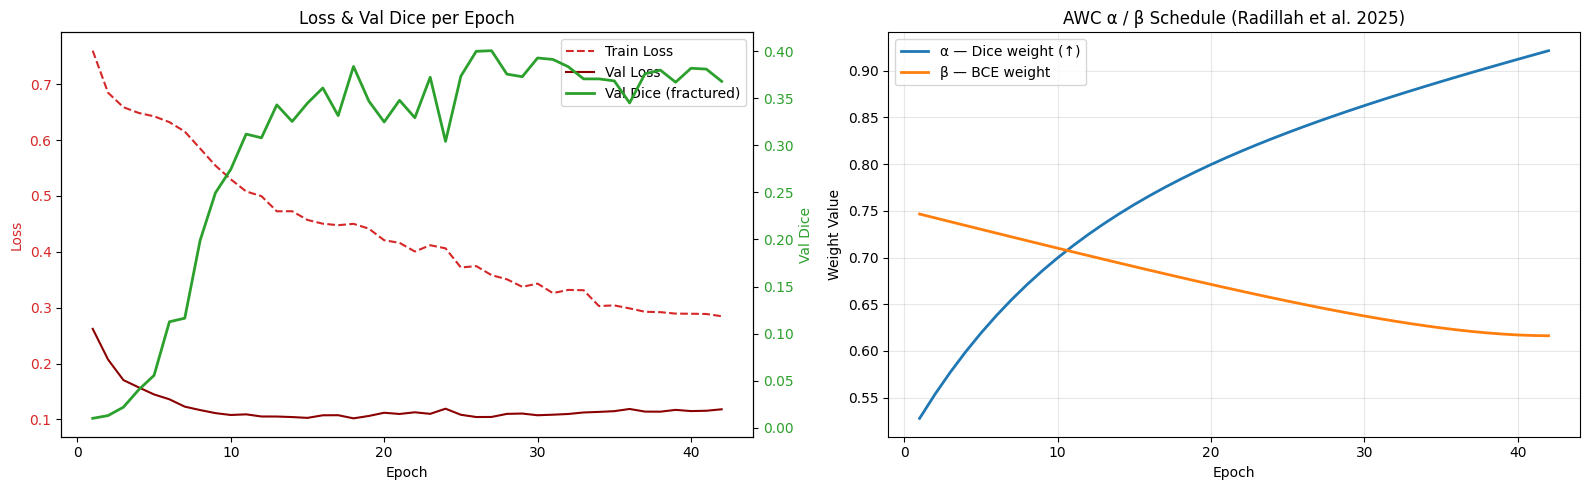

In [28]:
# Cell 13: Training curves — loss + Dice + alpha/beta schedule

epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: Loss + Dice ───────────────────────────────────────────────────
ax1.plot(epochs_range, history['train_loss'],
         label='Train Loss', color='tab:red', linestyle='--')
ax1.plot(epochs_range, history['val_loss'],
         label='Val Loss',   color='darkred')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax1b = ax1.twinx()
ax1b.plot(epochs_range, history['val_dice'],
          label='Val Dice (fractured)', color='tab:green', linewidth=2)
ax1b.set_ylabel('Val Dice', color='tab:green')
ax1b.tick_params(axis='y', labelcolor='tab:green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Loss & Val Dice per Epoch')

# ── Right: α and β schedule ─────────────────────────────────────────────
ax2.plot(epochs_range, history['alpha'],
         label='α — Dice weight (↑)', color='tab:blue', linewidth=2)
ax2.plot(epochs_range, history['beta'],
         label='β — BCE weight',      color='tab:orange', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Weight Value')
ax2.set_title('AWC α / β Schedule (Radillah et al. 2025)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Cell 14: Evaluation — loads best checkpoint, corrected thresholds

from sklearn.metrics import (accuracy_score,
                              precision_recall_fscore_support,
                              confusion_matrix)

# ── Load best model (saved by val Dice, not last epoch) ─────────────────
base_model.load_state_dict(torch.load(config.SAVE_PATH, map_location=device))
model = nn.DataParallel(base_model) if torch.cuda.device_count() > 1 else base_model
model = model.to(device)
model.eval()
print("Best checkpoint loaded.")

SIGMOID_THRESH = 0.35    # lower than 0.5 — catches weak hairline fracture signals
PIXEL_RATIO    = 0.001   # 0.1% of 256×256 = ~65 pixels minimum to call "Fractured"
                         # previous 0.5% = 327px was filtering out real detections

def evaluate_batch(pred_masks, true_masks, labels, smooth=1e-6):
    probs     = torch.sigmoid(pred_masks)
    preds_bin = (probs > SIGMOID_THRESH).float()
    trues_bin = (true_masks > 0.5).float()

    # Segmentation metrics — fractured images only
    frac_idx = labels.bool()
    if frac_idx.any():
        B = preds_bin[frac_idx].size(0)
        p = preds_bin[frac_idx].view(B, -1)
        m = trues_bin[frac_idx].view(B, -1)
        inter = (p * m).sum(dim=1)
        union = p.sum(dim=1) + m.sum(dim=1)
        dice  = ((2. * inter + smooth) / (union + smooth)).mean().item()
        iou   = ((inter + smooth) / (union - inter + smooth)).mean().item()
    else:
        dice, iou = 0.0, 0.0

    # Classification via pixel-count ratio
    total_px  = preds_bin.size(-1) * preds_bin.size(-2)
    active_px = preds_bin.view(preds_bin.size(0), -1).sum(dim=1)
    pred_cls  = (active_px > PIXEL_RATIO * total_px).float().cpu().numpy()
    true_cls  = labels.cpu().numpy()

    return dice, iou, pred_cls, true_cls


total_dice, total_iou, n = 0.0, 0.0, 0
all_pred, all_true = [], []

with torch.no_grad():
    for images, masks, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        masks  = masks.to(device)
        pred   = model(images)

        d, iou, p_cls, t_cls = evaluate_batch(pred, masks, labels)
        total_dice += d;  total_iou += iou
        all_pred.extend(p_cls);  all_true.extend(t_cls)
        n += 1

mean_dice = total_dice / n
mean_iou  = total_iou  / n
acc   = accuracy_score(all_true, all_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_true, all_pred, average='binary', zero_division=0)
cm = confusion_matrix(all_true, all_pred)

print("\n" + "="*52)
print("      FINAL EVALUATION  (paper metric format)")
print("="*52)
print(f"  Dice Coefficient  : {mean_dice:.4f}")
print(f"  IoU Score         : {mean_iou:.4f}")
print(f"  Accuracy          : {acc*100:.2f}%")
print(f"  Precision         : {prec*100:.2f}%")
print(f"  Recall            : {rec*100:.2f}%")
print(f"  F1-Score          : {f1*100:.2f}%")
print("="*52)
print(f"  Confusion Matrix:")
print(f"    TP={cm[1,1]}  FN={cm[1,0]}")
print(f"    FP={cm[0,1]}  TN={cm[0,0]}")
print("="*52)

Best checkpoint loaded.


Evaluating: 100%|██████████| 38/38 [00:13<00:00,  2.89it/s]


      FINAL EVALUATION  (paper metric format)
  Dice Coefficient  : 0.0740
  IoU Score         : 0.0565
  Accuracy          : 60.40%
  Precision         : 27.11%
  Recall            : 71.30%
  F1-Score          : 39.29%
  Confusion Matrix:
    TP=77  FN=31
    FP=207  TN=286


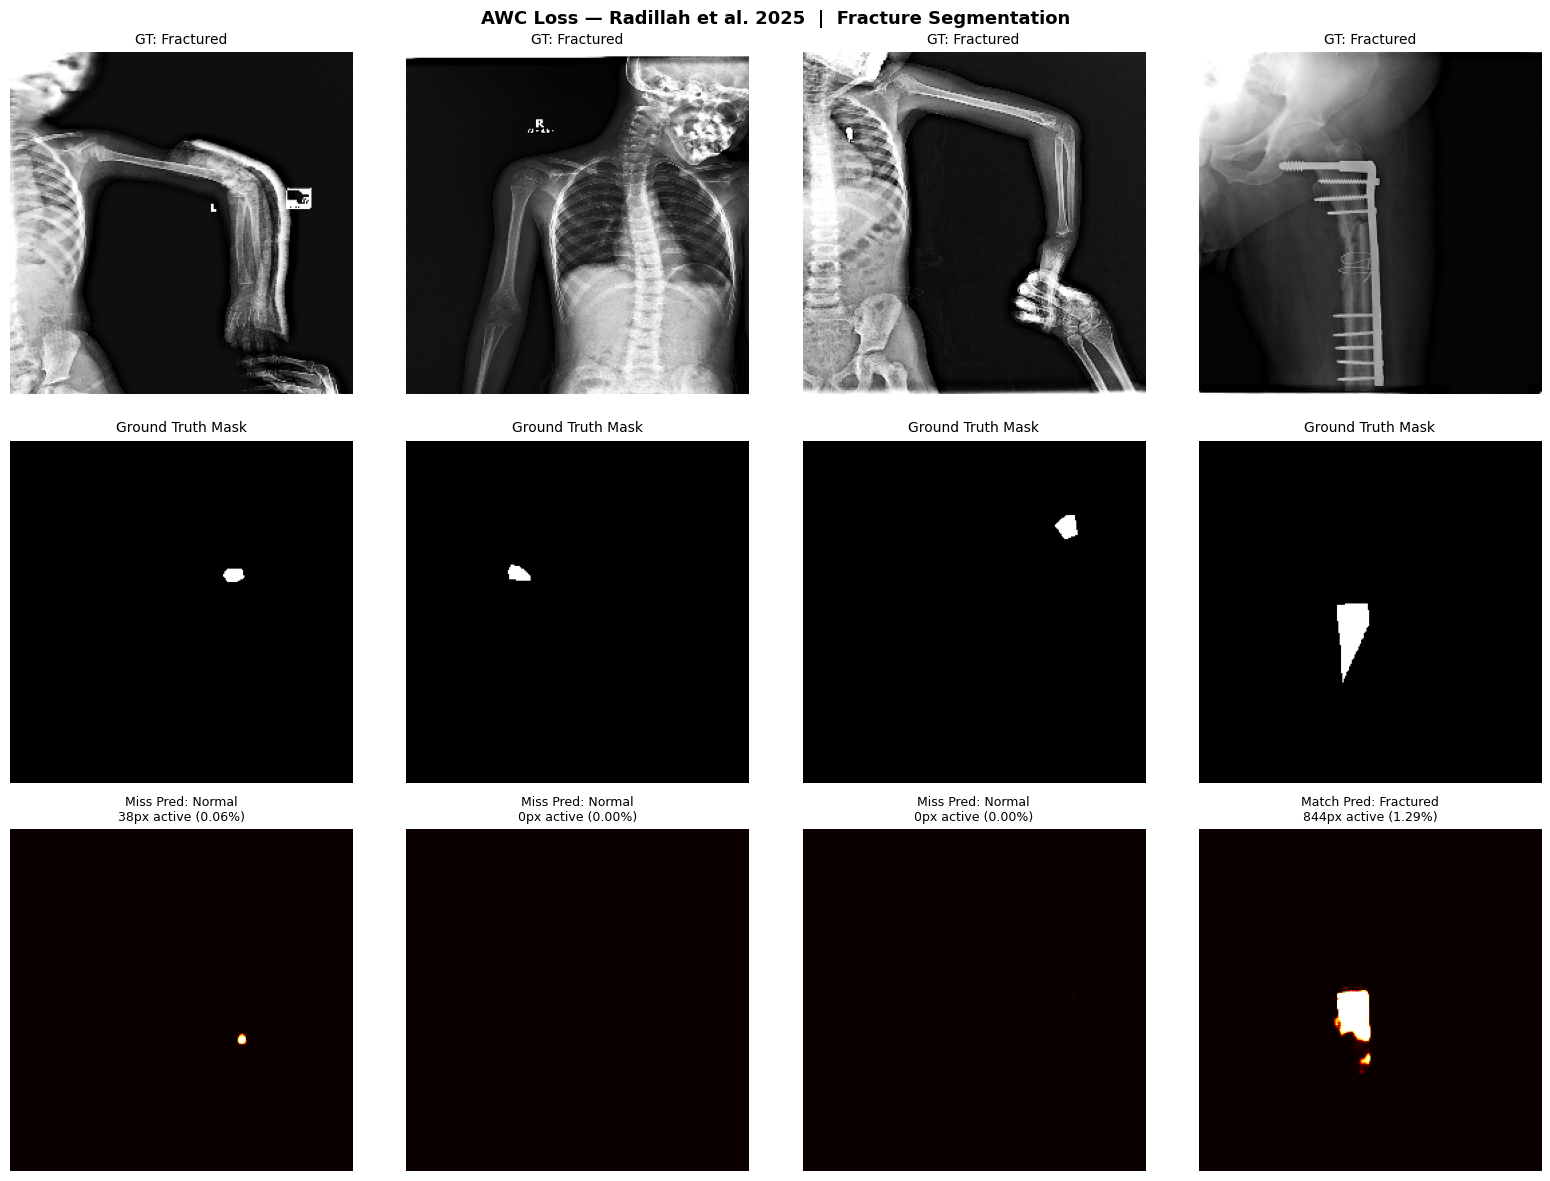

In [30]:
# Cell 15: Visualisation — uses same thresholds as evaluation

model.eval()
images, masks, labels = next(iter(test_loader))

with torch.no_grad():
    pred_logits = model(images.to(device))
    pred_probs  = torch.sigmoid(pred_logits).cpu().numpy()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(4):
    total_px   = pred_probs[i][0].size
    active_px  = int((pred_probs[i][0] > SIGMOID_THRESH).sum())
    pred_label = "Fractured" if active_px > PIXEL_RATIO * total_px else "Normal"
    confidence = (active_px / total_px) * 100
    true_label = "Fractured" if labels[i] == 1 else "Normal"
    match = "Match" if pred_label == true_label else "Miss"
    
    axes[0, i].imshow(images[i][0].numpy(), cmap='gray')
    axes[0, i].set_title(f"GT: {true_label}", fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(masks[i][0].numpy(), cmap='bone')
    axes[1, i].set_title("Ground Truth Mask", fontsize=10)
    axes[1, i].axis('off')

    axes[2, i].imshow(pred_probs[i][0], cmap='hot', vmin=0, vmax=1)
    axes[2, i].set_title(
        f"{match} Pred: {pred_label}\n{active_px}px active ({confidence:.2f}%)",
        fontsize=9)
    axes[2, i].axis('off')

plt.suptitle("AWC Loss — Radillah et al. 2025  |  Fracture Segmentation",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Found 7 images. Running inference...



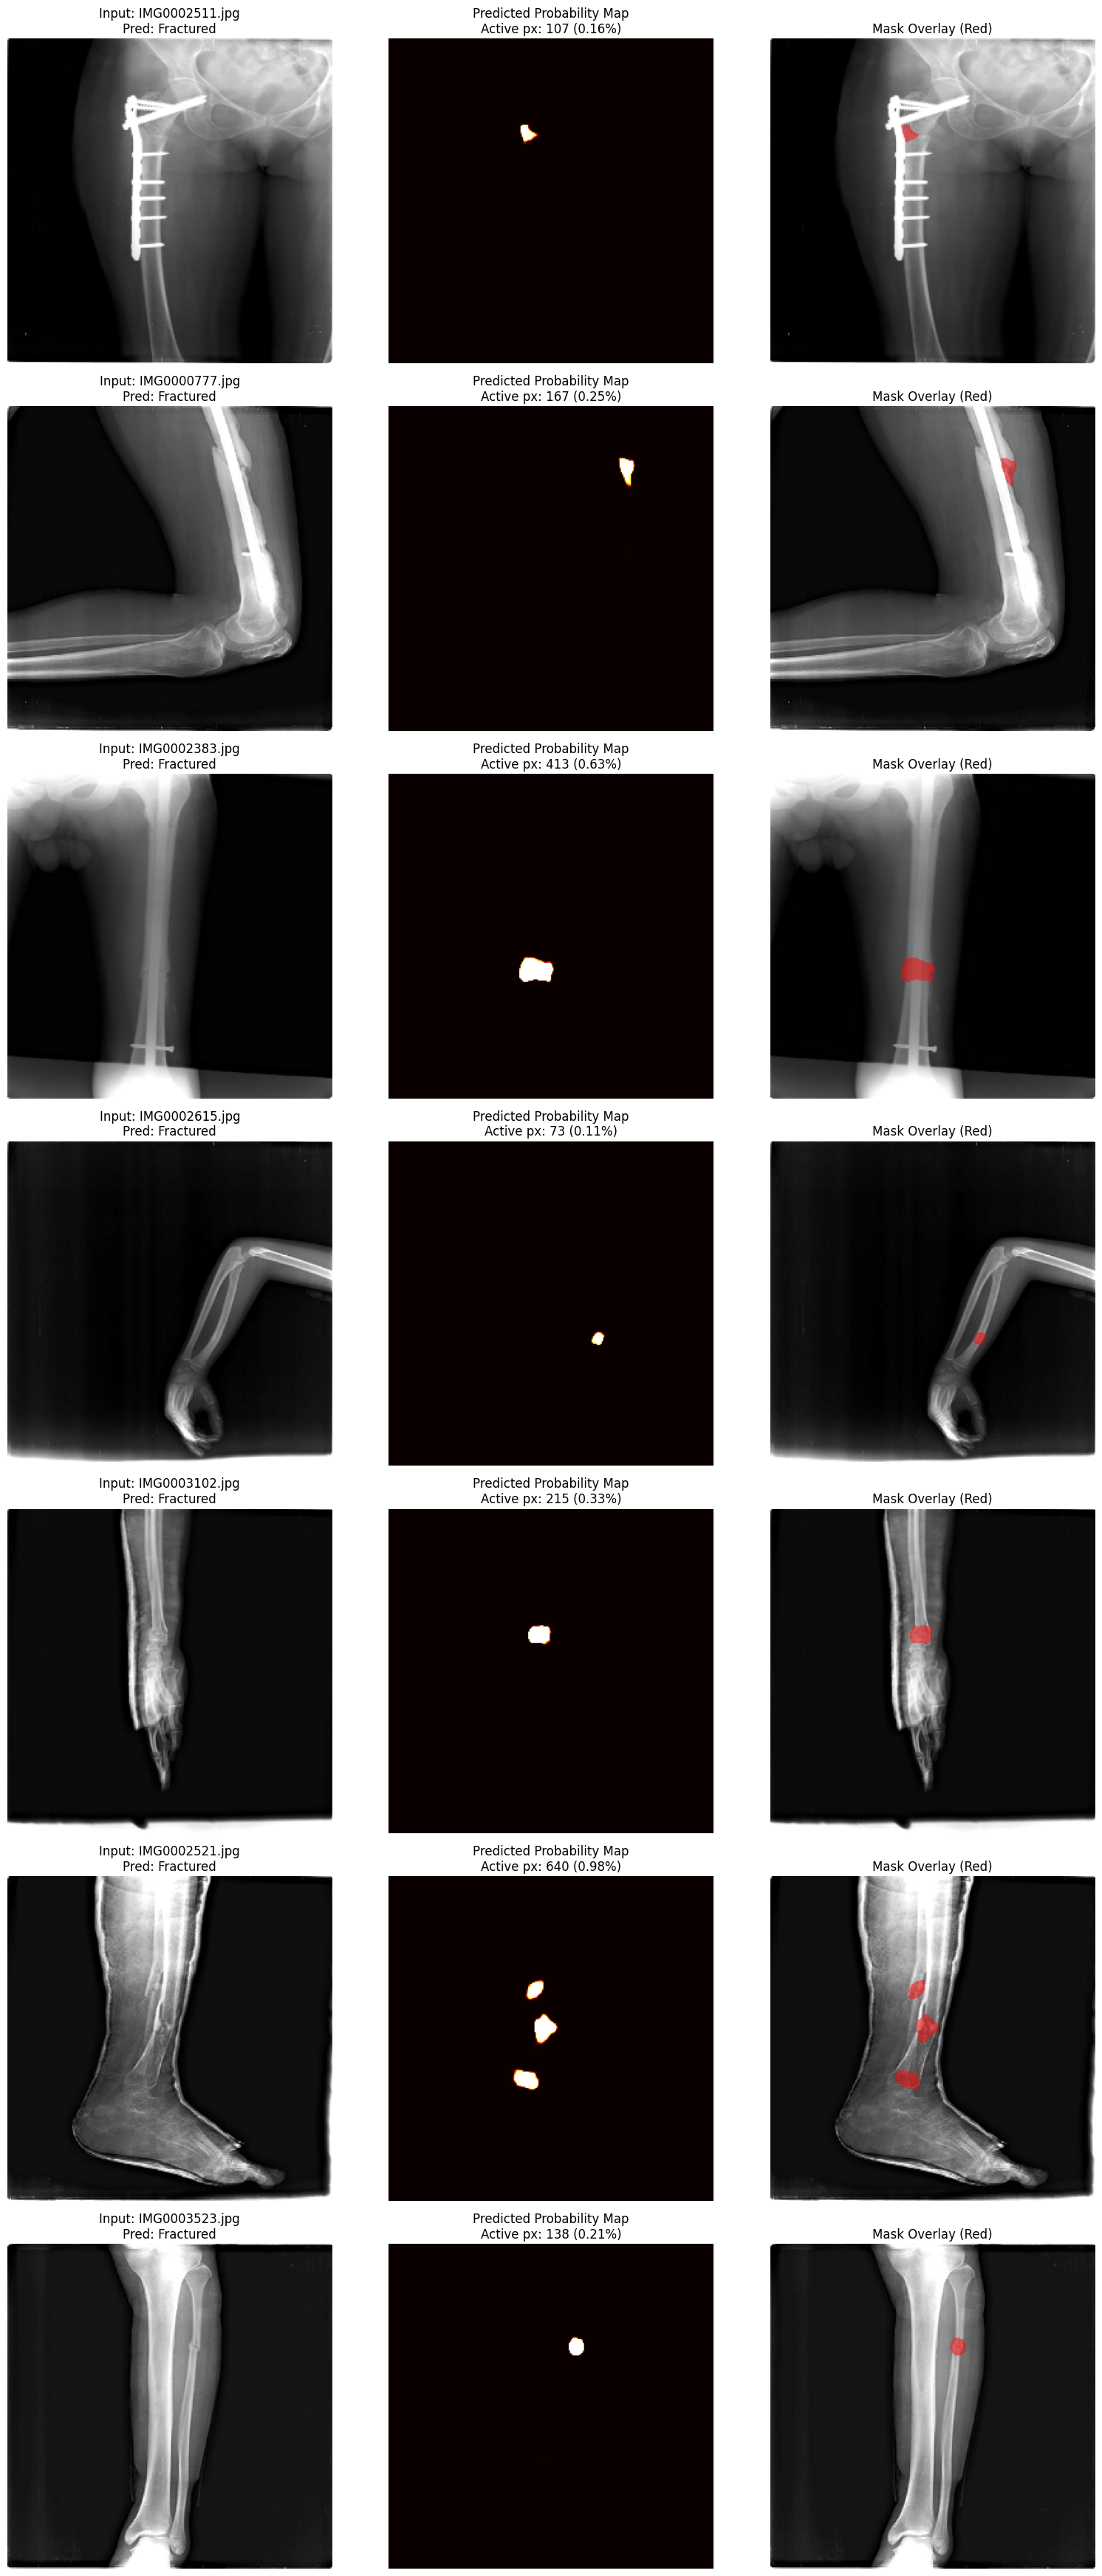

In [33]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# 1. Define the exact folder path
test_folder_path = "/kaggle/input/datasets/gowthambatthula/finaldata/Final_Dataset/test/images/fractured"

if not os.path.exists(test_folder_path):
    print(f"⚠️ Folder not found at: {test_folder_path}")
else:
    # Get all image files in the directory
    #image_files = sorted([f for f in os.listdir(test_folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))])

    all_images = [f for f in os.listdir(test_folder_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))]

    # Randomly select up to 7 images
    image_files = random.sample(all_images, min(7, len(all_images)))
    
    if not image_files:
        print(f"❌ No images found in {test_folder_path}")
    else:
        print(f"Found {len(image_files)} images. Running inference...\n")
        
        # Setup plot: rows = number of images, cols = 3 (Input | Pred Mask | Red Overlay)
        fig, axes = plt.subplots(len(image_files), 3, figsize=(16, 5 * len(image_files)))
        
        # Ensure axes is 2D in case there is only 1 image
        if len(image_files) == 1:
            axes = np.expand_dims(axes, axis=0)
            
        model.eval()
        
        # Using the same thresholds from your evaluation cell (Cell 14)
        SIGMOID_THRESH = 0.35 
        PIXEL_RATIO = 0.001 
        
        for idx, img_name in enumerate(image_files):
            img_path = os.path.join(test_folder_path, img_name)
            
            # 2. Load the image strictly in Grayscale
            raw_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if raw_image is None:
                print(f"❌ Error loading image: {img_name}")
                continue
                
            # 3. Preprocess using your existing pipeline
            dummy_mask = np.zeros_like(raw_image)
            augmented = val_test_transforms(image=raw_image, mask=dummy_mask)
            input_tensor = augmented['image'].unsqueeze(0).to(device)
            
            # 4. Model Inference
            with torch.no_grad():
                pred_mask_logits = model(input_tensor)
                # Convert logits to probability map (0.0 to 1.0)
                pred_mask_prob = torch.sigmoid(pred_mask_logits).cpu().numpy()[0][0]
                
            # 5. Calculate Classification Label
            total_px = pred_mask_prob.size
            mask_binary = pred_mask_prob > SIGMOID_THRESH
            active_px = mask_binary.sum()
            
            pred_label = "Fractured" if active_px > (PIXEL_RATIO * total_px) else "Normal"
            confidence = (active_px / total_px) * 100
            
            # 6. Visualize the Result
            preprocessed_image = input_tensor.cpu().numpy()[0][0]
            
            # --- OVERLAY CREATION ---
            # Normalize the image to [0, 1] to convert it to an RGB format
            img_min, img_max = preprocessed_image.min(), preprocessed_image.max()
            base_img_norm = (preprocessed_image - img_min) / (img_max - img_min + 1e-8)
            
            # Stack the 1-channel grayscale into 3-channel RGB
            overlay_img = np.stack([base_img_norm] * 3, axis=-1)
            
            # Apply Red color [1.0, 0.0, 0.0] to the masked areas (blending at 50% opacity)
            overlay_img[mask_binary] = overlay_img[mask_binary] * 0.5 + np.array([1.0, 0.0, 0.0]) * 0.5
            # ------------------------

            # Input Image (Left Column)
            axes[idx, 0].imshow(preprocessed_image, cmap='gray')
            axes[idx, 0].set_title(f"Input: {img_name}\nPred: {pred_label}")
            axes[idx, 0].axis('off')
            
            # Model Predicted Mask Output (Middle Column)
            axes[idx, 1].imshow(pred_mask_prob, cmap='hot', vmin=0, vmax=1)
            axes[idx, 1].set_title(f"Predicted Probability Map\nActive px: {active_px} ({confidence:.2f}%)")
            axes[idx, 1].axis('off')
            
            # Overlay Image (Right Column)
            axes[idx, 2].imshow(overlay_img)
            axes[idx, 2].set_title("Mask Overlay (Red)")
            axes[idx, 2].axis('off')
            
        plt.tight_layout()
        plt.show()